In [211]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [212]:
# Load the data
df = pd.read_csv('../../data/laptop_data.csv', encoding='ISO-8859-1')
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,"71,378.68"
1,1,Apple,Ultrabook,13.30,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,"47,895.52"
2,2,HP,Notebook,15.60,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,"30,636.00"
3,3,Apple,Ultrabook,15.40,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,"135,195.34"
4,4,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,"96,095.81"


In [213]:
import requests
import pandas as pd

def get_exchange_rate():
    response = requests.get('https://api.exchangerate-api.com/v4/latest/INR')
    data = response.json()
    return data['rates']['LKR']

# Get current exchange rate
exchange_rate = get_exchange_rate()
print(f"Current exchange rate: 1 INR = {exchange_rate} LKR")

# Convert the Price column
df['Price'] = df['Price'] * exchange_rate
pd.set_option('display.float_format', '{:,.2f}'.format)

df.head()

Current exchange rate: 1 INR = 3.51 LKR


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,"250,539.18"
1,1,Apple,Ultrabook,13.30,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,"168,113.29"
2,2,HP,Notebook,15.60,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,"107,532.36"
3,3,Apple,Ultrabook,15.40,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,"474,535.63"
4,4,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,"337,296.29"


In [214]:
# Data cleaning and preprocessing steps

# 1. Check for missing values
print("\nMissing values before cleaning:")
df.isnull().sum()

# 2. Clean Weight column
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

# 3. Clean RAM column
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)

# 4. Extract CPU Speed
def extract_cpu_speed(cpu_str):
    try:
        # First try standard pattern
        speed = float(cpu_str.split('GHz')[0].split()[-1])
    except:
        try:
            # Try alternative patterns
            if 'MHz' in cpu_str:
                speed = float(cpu_str.split('MHz')[0].split()[-1]) / 1000
            else:
                # If no GHz/MHz found, use median
                speeds = df['Cpu'].str.extract(r'(\d+\.?\d*)\s?GHz')[0].dropna().astype(float)
                speed = speeds.median()
        except:
            speed = 2.5  # Default fallback
    return speed

df['Cpu_Speed'] = df['Cpu'].apply(extract_cpu_speed)

# 5. Process Memory into SSD/HDD
def process_memory(mem):
    ssd = hdd = 0
    mem = str(mem)  # Ensure string type
    
    # Handle TB conversions
    if 'TB' in mem:
        multiplier = 1000
    else:
        multiplier = 1
    
    if 'SSD' in mem or 'Flash Storage' in mem:
        size = ''.join(filter(str.isdigit, mem.split('GB')[0]))
        ssd = int(size) * multiplier if size else 0
    elif 'HDD' in mem:
        size = ''.join(filter(str.isdigit, mem.split('GB')[0]))
        hdd = int(size) * multiplier if size else 0
    elif '+' in mem:  # Hybrid case
        parts = mem.split('+')
        for part in parts:
            if 'SSD' in part:
                size = ''.join(filter(str.isdigit, part.split('GB')[0]))
                ssd = int(size) * multiplier if size else 0
            elif 'HDD' in part:
                size = ''.join(filter(str.isdigit, part.split('GB')[0]))
                hdd = int(size) * multiplier if size else 0
    return ssd, hdd

df['SSD'] = df['Memory'].apply(lambda x: process_memory(x)[0])
df['HDD'] = df['Memory'].apply(lambda x: process_memory(x)[1])

# 6. Screen Features
df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen').astype(int)
df['IPS'] = df['ScreenResolution'].str.contains('IPS').astype(int)

# Extract resolution with error handling
def get_resolution(res_str):
    try:
        res = res_str.split(' ')[-1].split('x')
        return float(res[0]), float(res[1])
    except:
        return 1920.0, 1080.0  

df[['Resolution_X', 'Resolution_Y']] = df['ScreenResolution'].apply(
    lambda x: pd.Series(get_resolution(x)))

# 7. GPU 
df['Gpu_Brand'] = df['Gpu'].str.split().str[0]

# 8. Verify no missing values remain
print("\nMissing values after cleaning:")
df.isnull().sum()

# 9. Check cleaned data
print("\nCleaned data sample:")
df[['Company', 'Ram', 'Cpu_Speed', 'SSD', 'HDD', 'Resolution_X', 'Resolution_Y']].head()


Missing values before cleaning:

Missing values after cleaning:

Cleaned data sample:


,Company,Ram,Cpu_Speed,SSD,HDD,Resolution_X,Resolution_Y
0,Apple,8,2.30,128,0,"2,560.00","1,600.00"
1,Apple,8,1.80,128,0,"1,440.00",900.00
2,HP,8,2.50,256,0,"1,920.00","1,080.00"
3,Apple,16,2.70,512,0,"2,880.00","1,800.00"
4,Apple,8,3.10,256,0,"2,560.00","1,600.00"


In [215]:
# Selected features
features = [
    'Company', 'TypeName', 'Inches', 'Ram', 'Cpu_Speed', 
    'SSD', 'HDD', 'Gpu_Brand', 'Touchscreen', 'IPS',
    'Resolution_X', 'Resolution_Y', 'Weight', 'OpSys'
]

target = 'Price'

In [216]:
X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")


Training samples: 1042
Test samples: 261


In [217]:
# Identify feature types
numeric_features = [
    'Inches', 'Ram', 'Cpu_Speed', 'SSD', 'HDD', 
    'Touchscreen', 'IPS', 'Resolution_X', 'Resolution_Y', 'Weight'
]
categorical_features = ['Company', 'TypeName', 'Gpu_Brand', 'OpSys']

In [218]:
# Preprocessing pipeline with imputation
from sklearn.impute import SimpleImputer #SimpleImputer will replace missing values with the median of the column
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),  
            ('scaler', 'passthrough')  
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),  
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

In [219]:
# Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [220]:
# Creating a Random Forest pipeline because it can handle both preprocessing and model fitting
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_model)
])

In [221]:
# Train the model
rf_pipeline.fit(X_train, y_train)
print("\nModel training completed!")


Model training completed!


In [222]:
# Make predictions
y_pred = rf_pipeline.predict(X_test)

In [223]:
# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print(f"MAE: {mae:.2f} euros")
print(f"RMSE: {rmse:.2f} euros")
print(f"R2 Score: {r2:.4f}")


Model Performance
MAE: 37118.12 euros
RMSE: 60549.65 euros
R2 Score: 0.7936


In [224]:
# Feature Importance
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_feature_names])

importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

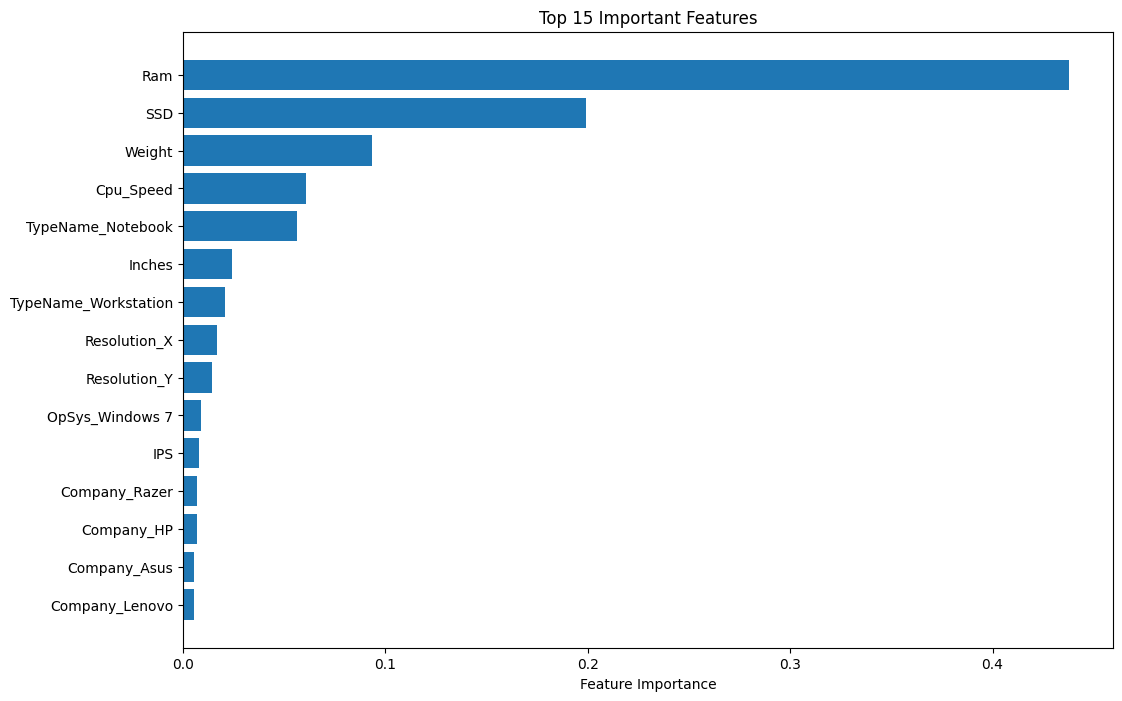

In [225]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'][:15], importance_df['Importance'][:15])
plt.xlabel('Feature Importance')
plt.title('Top 15 Important Features')
plt.gca().invert_yaxis()
plt.show()

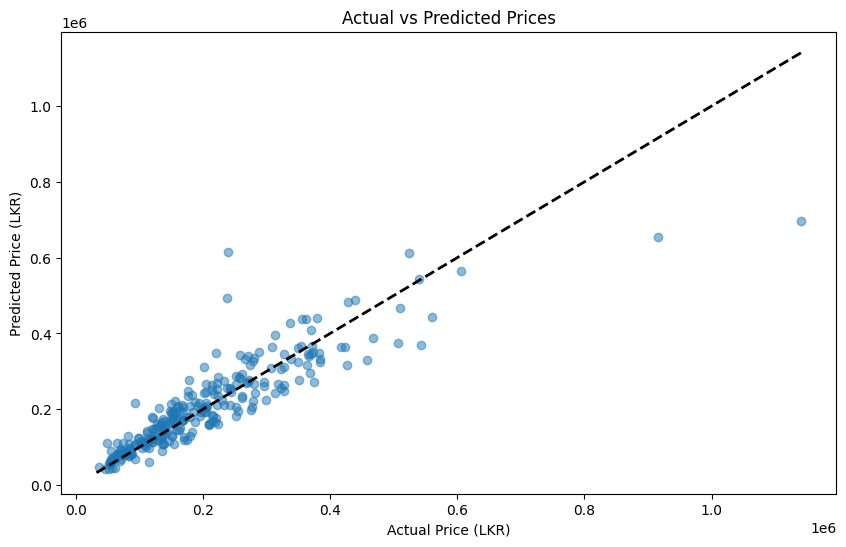

In [226]:
# Visualize actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # Perfect prediction line
plt.xlabel('Actual Price (LKR)')
plt.ylabel('Predicted Price (LKR)')
plt.title('Actual vs Predicted Prices')
plt.show()

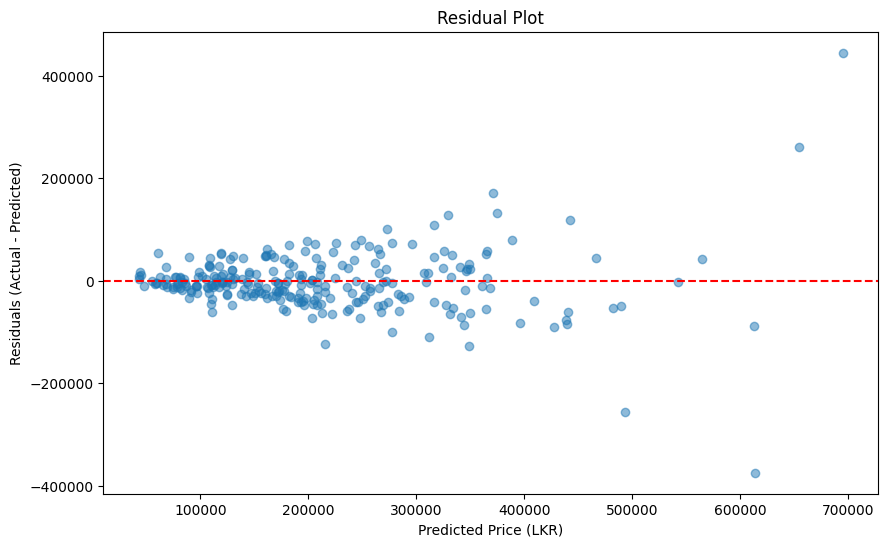

In [227]:
# Visualize residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price (LKR)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

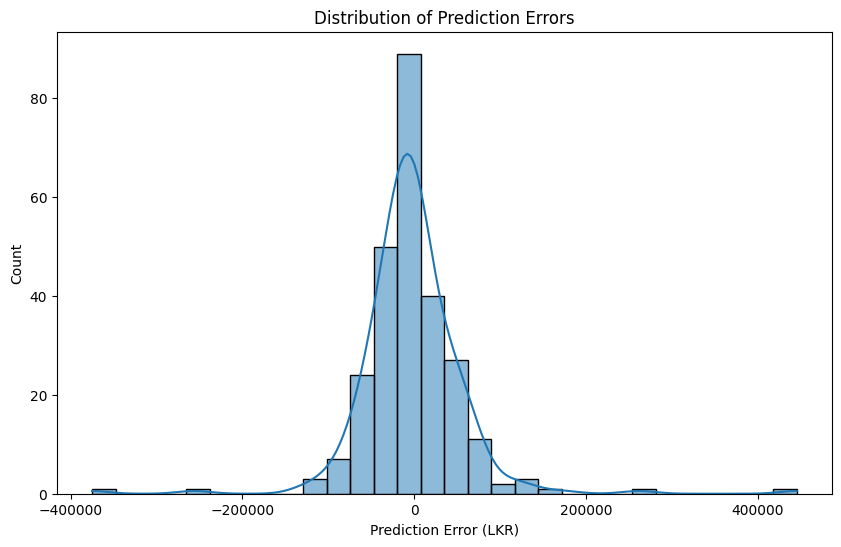

In [228]:
# Distribution of prediction errors
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel('Prediction Error (LKR)')
plt.title('Distribution of Prediction Errors')
plt.show()

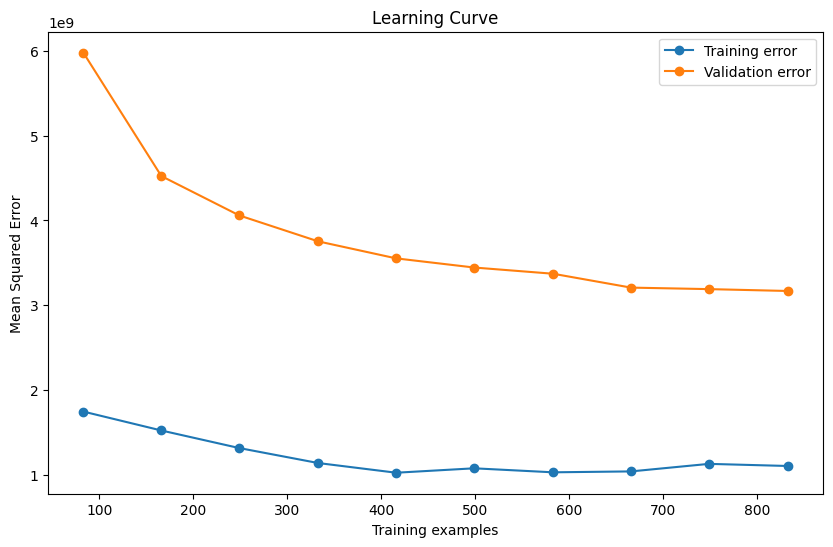

In [229]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf_pipeline, X_train, y_train, cv=5,
    scoring='neg_mean_squared_error', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label='Training error')
plt.plot(train_sizes, test_scores_mean, 'o-', label='Validation error')
plt.xlabel('Training examples')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [230]:
# Function to make predictions
def predict_laptop_price(features_dict):
    """Predict laptop price from input features"""
    input_df = pd.DataFrame([features_dict])
    prediction = rf_pipeline.predict(input_df)[0]
    return round(prediction, 2)

# Example prediction
example_features = {
    'Company': 'Dell',
    'TypeName': 'Notebook',
    'Inches': 15.6,
    'Ram': 8,
    'Cpu_Speed': 2.5,
    'SSD': 512,
    'HDD': 0,
    'Gpu_Brand': 'Nvidia',
    'Touchscreen': 0,
    'IPS': 1,
    'Resolution_X': 1920,
    'Resolution_Y': 1080,
    'Weight': 2.1,
    'OpSys': 'Windows 10'
}

predicted_price = predict_laptop_price(example_features)
print(f"\nPredicted price for example laptop: LKR {predicted_price}")


Predicted price for example laptop: LKR 215827.32
